# DSP Pipeline Analysis – Speech Signal Preprocessing

**Digital Signal Processing (DSP) for Speech Signals**

This notebook implements a complete, academically oriented DSP pipeline for **speech signal analysis and preprocessing**.

We assume the input is a **single‑channel speech WAV file** and we:

- Design **FIR and IIR band‑pass filters (300–3400 Hz)** for telephony‑band speech.
- Analyse **magnitude and phase responses**, and discuss **stability** (IIR).
- Perform **frequency‑domain analysis**: FFT, STFT spectrogram, wavelet scalogram, and power spectral density (PSD).
- Demonstrate **spectral leakage**, **window size effects**, and the **time–frequency resolution trade‑off**.

All steps use modular Python functions and are accompanied by labeled plots and short DSP interpretations.

**Libraries:** `numpy`, `scipy`, `librosa`, `matplotlib`, `pywt`, `scikit-learn`.

> **Note:** Update `AUDIO_PATH` below to point to your own speech `.wav` file before running the notebook.

In [6]:
# Imports and configuration

import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display

from scipy import signal
import pywt

from sklearn.preprocessing import StandardScaler  # for optional normalization

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

# Path to input speech WAV file (update this)
AUDIO_PATH = "../data/voice2.m4a"   # change to your file

# -------------------------------------------------------------------
# Utility plotting helpers
# -------------------------------------------------------------------

def plot_waveform(y, sr, title="Waveform", xlim=None):
    t = np.arange(len(y)) / sr
    plt.figure()
    plt.plot(t, y)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()


def db(x):
    """Convert magnitude to dB, with floor to avoid log(0)."""
    return 20 * np.log10(np.maximum(x, 1e-10))

In [7]:
# -------------------------------------------------------------------
# Core modular DSP functions
# -------------------------------------------------------------------


def load_audio(path=AUDIO_PATH, sr=None):
    """
    Load a mono speech signal from file.
    """
    y, sr = librosa.load(path, sr=sr, mono=True)
    print(f"Loaded '{path}'")
    print(f"Sample rate: {sr} Hz")
    print(f"Duration: {len(y)/sr:.2f} s, Samples: {len(y)}")
    return y, sr


def design_filter(sr, low_hz=300.0, high_hz=3400.0,
                  fir_numtaps=501, iir_order=4):
    """Design FIR and IIR band-pass filters for speech (300–3400 Hz)."""
    nyq = 0.5 * sr
    low = low_hz / nyq
    high = high_hz / nyq

    # FIR band-pass with linear phase
    fir_taps = signal.firwin(
        fir_numtaps,
        [low, high],
        pass_zero=False,
        window="hamming",
    )

    # IIR Butterworth band-pass
    b_iir, a_iir = signal.butter(
        iir_order,
        [low, high],
        btype="bandpass",
    )

    return {
        "fir": {"b": fir_taps, "a": np.array([1.0])},
        "iir": {"b": b_iir, "a": a_iir},
    }


def apply_filter(y, filt, zero_phase=True):
    """Apply a digital filter to a 1D signal."""
    b, a = filt["b"], filt["a"]
    if zero_phase:
        y_filt = signal.filtfilt(b, a, y)
    else:
        y_filt = signal.lfilter(b, a, y)
    return y_filt

def pre_emphasize(y, alpha: float = 0.97):
    """
    Apply a first-order pre-emphasis filter to a 1-D signal.

    y'[n] = y[n] - alpha * y[n-1]

    Parameters
    ----------
    y : 1-D numpy array
        Input audio signal.
    alpha : float, optional
        Pre-emphasis coefficient in [0, 1). Typical values: 0.95–0.97.

    Returns
    -------
    y_emph : 1-D numpy array
        Pre-emphasized signal, same length as input.
    """
    if y.size == 0:
        return y

    # Use vectorized implementation for efficiency
    return np.concatenate(([y[0]], y[1:] - alpha * y[:-1]))
def plot_frequency_response(b, a, sr, title="Frequency response"):
    """Plot magnitude response (in dB) vs frequency."""
    w, h = signal.freqz(b, a, worN=2048)
    freqs = w / (2.0 * np.pi) * sr

    plt.figure()
    plt.plot(freqs, db(np.abs(h)))
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.title(title)
    plt.xlim(0, sr / 2)
    plt.ylim(-100, 5)
    plt.tight_layout()
    plt.show()


def plot_phase_response(b, a, sr, title="Phase response"):
    """Plot unwrapped phase response vs frequency."""
    w, h = signal.freqz(b, a, worN=2048)
    freqs = w / (2.0 * np.pi) * sr
    phase = np.unwrap(np.angle(h))

    plt.figure()
    plt.plot(freqs, phase)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Phase [rad]")
    plt.title(title)
    plt.xlim(0, sr / 2)
    plt.tight_layout()
    plt.show()


def compute_fft(y, sr):
    """Compute one-sided FFT magnitude spectrum."""
    n = len(y)
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    mag = np.abs(Y)
    return freqs, mag


def compute_stft(y, sr, n_fft=1024, hop_length=256, window="hann"):
    """Compute STFT and return magnitude spectrogram in dB."""
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=window)
    S_mag = np.abs(S)
    S_db = librosa.amplitude_to_db(S_mag, ref=np.max)
    return S_db


def compute_wavelet(y, sr, wavelet="morl", max_scale=128):
    """Compute Continuous Wavelet Transform (CWT) using pywt."""
    scales = np.arange(1, max_scale + 1)
    coefficients, _ = pywt.cwt(y, scales, wavelet, sampling_period=1.0 / sr)
    freqs = pywt.scale2frequency(wavelet, scales) / (1.0 / sr)
    return coefficients, freqs


def compute_psd(y, sr, nperseg=1024):
    """Compute Power Spectral Density (PSD) using Welch's method."""
    freqs, psd = signal.welch(y, fs=sr, nperseg=nperseg)
    return freqs, psd

---
## SECTION 1 — Digital Filtering

In this section we design **FIR** and **IIR** band‑pass filters for speech preprocessing (300–3400 Hz), apply them to the waveform, and analyze their frequency and phase responses.

- **Digital filtering**: convolution of a discrete‑time signal with a filter’s impulse response to selectively pass or attenuate certain frequencies.
- **FIR filters**: finite impulse response, always stable, can be designed with **exact linear phase** (symmetric coefficients).
- **IIR filters**: infinite impulse response (feedback), more efficient for sharp transitions but can have **nonlinear phase** and must be checked for stability.
- **Speech band‑pass**: human speech energy is mainly between **300–3400 Hz**, so removing very low and very high frequencies improves intelligibility and reduces noise.

/var/folders/rw/mrq8frv956d97wy41t6467mc0000gn/T/ipykernel_53689/637357493.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=sr, mono=True)
/Users/quangle/Documents/projects/MSE_project/DSP/DSP501-Speaker-Identification-Project/venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded '../data/voice2.m4a'
Sample rate: 48000 Hz
Duration: 6.93 s, Samples: 332736
Plotting raw and FIR-filtered waveform (short segment)


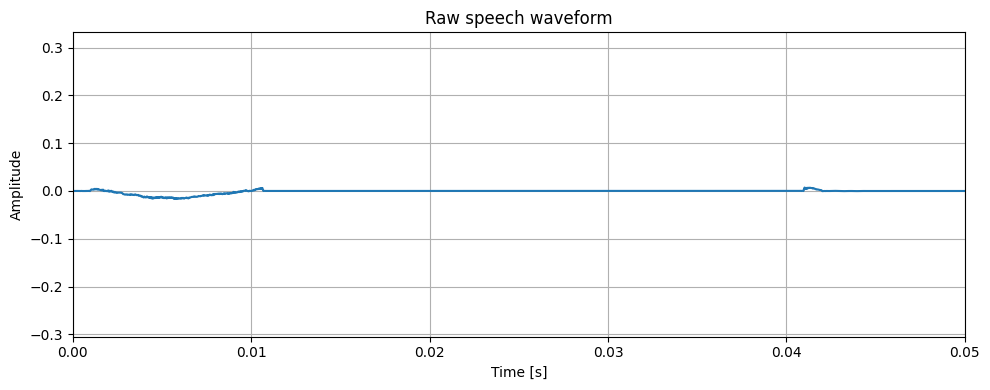

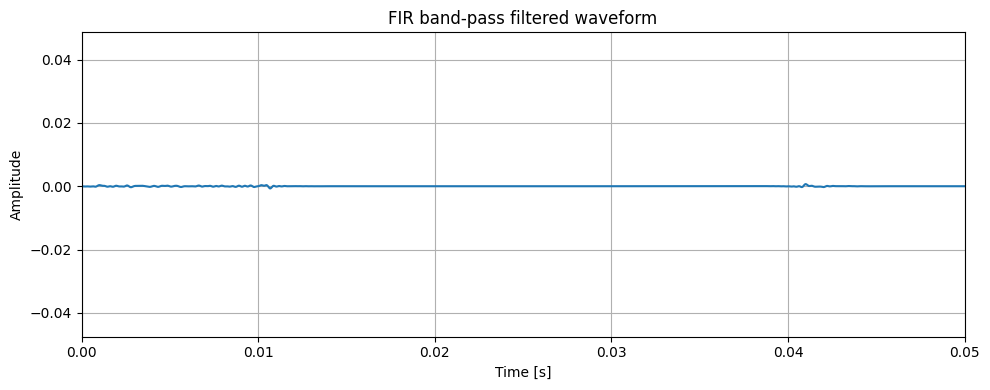

Plotting IIR-filtered waveform (same segment)


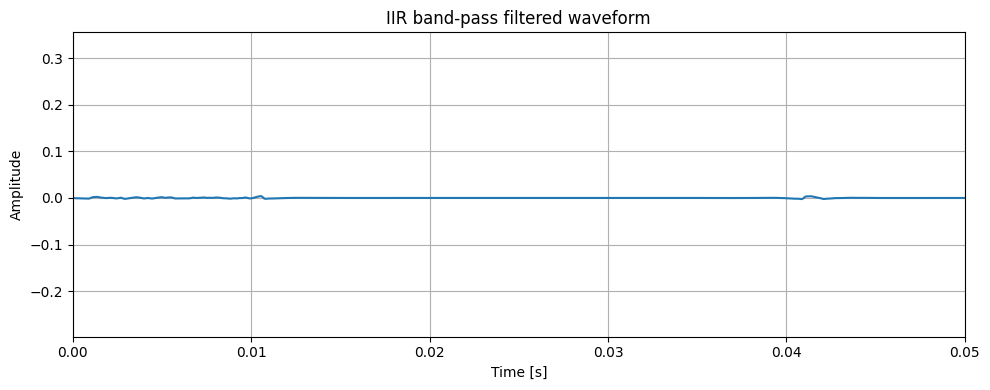

In [8]:
# SECTION 1.1 — Filter design and application

# Load audio
y, sr = load_audio(AUDIO_PATH, sr=None)

# Design FIR and IIR band-pass filters
filters = design_filter(sr, low_hz=300.0, high_hz=3400.0,
                        fir_numtaps=501, iir_order=4)

fir_filt = filters["fir"]
iir_filt = filters["iir"]

# Apply filters (zero-phase)
y_fir = apply_filter(y, fir_filt, zero_phase=True)
y_fir = pre_emphasize(y_fir)
y_iir = apply_filter(y, iir_filt, zero_phase=True)

# Plot raw vs FIR-filtered waveform (short segment for clarity)
segment = (0.0, min(0.05, len(y) / sr))  # 50 ms
print("Plotting raw and FIR-filtered waveform (short segment)")
plot_waveform(y, sr, title="Raw speech waveform", xlim=segment)
plot_waveform(y_fir, sr, title="FIR band-pass filtered waveform", xlim=segment)

print("Plotting IIR-filtered waveform (same segment)")
plot_waveform(y_iir, sr, title="IIR band-pass filtered waveform", xlim=segment)

---
### 1.2 Frequency Response Analysis

We now compute the **frequency response** of the designed filters using `scipy.signal.freqz`.

- **Passband**: range of frequencies where the magnitude ≈ 0 dB (here around **300–3400 Hz**).
- **Stopband**: regions below ~300 Hz and above ~3400 Hz where the filter attenuates strongly (large negative dB).
- **Transition band**: the intermediate region where the response smoothly transitions from passband to stopband.
- **Attenuation**: how strongly out‑of‑band components are suppressed (e.g., −40 dB, −60 dB, ...).

We examine whether the designed filters preserve the **speech band** while attenuating unwanted low‑frequency and high‑frequency components.

FIR band-pass frequency response


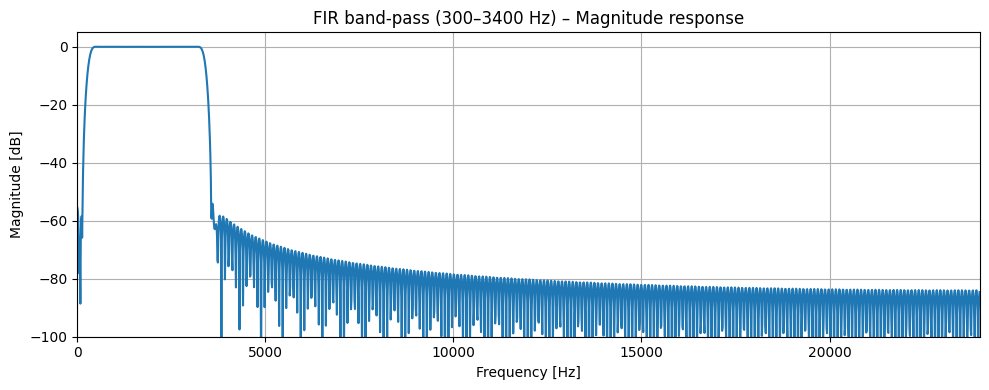

IIR Butterworth band-pass frequency response


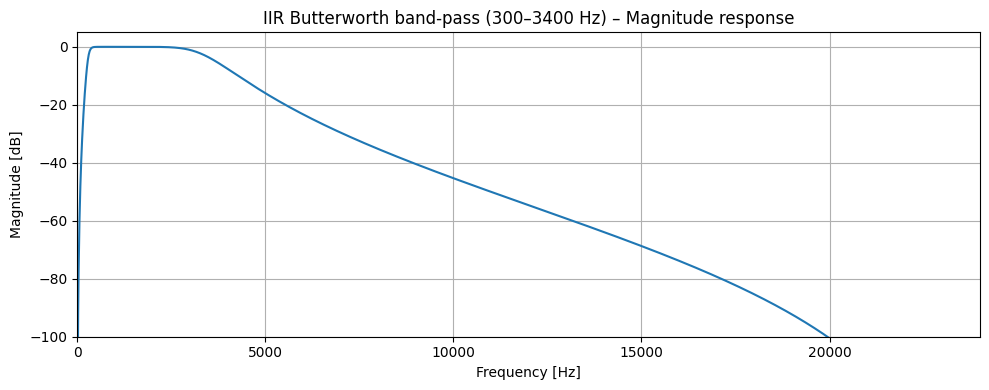

Qualitative interpretation:
- In the passband (300–3400 Hz), magnitude should be near 0 dB.
- In the stopbands (<300 Hz and >3400 Hz), magnitude should drop well below 0 dB.
- FIR transition region is controlled by numtaps; IIR transition is sharper for same order.


In [9]:
# Frequency responses of FIR and IIR band-pass filters

print("FIR band-pass frequency response")
plot_frequency_response(
    fir_filt["b"], fir_filt["a"], sr,
    title="FIR band-pass (300–3400 Hz) – Magnitude response",
)

print("IIR Butterworth band-pass frequency response")
plot_frequency_response(
    iir_filt["b"], iir_filt["a"], sr,
    title="IIR Butterworth band-pass (300–3400 Hz) – Magnitude response",
)

print("Qualitative interpretation:")
print("- In the passband (300–3400 Hz), magnitude should be near 0 dB.")
print("- In the stopbands (<300 Hz and >3400 Hz), magnitude should drop well below 0 dB.")
print("- FIR transition region is controlled by numtaps; IIR transition is sharper for same order.")

---
### 1.3 Phase Response Analysis

The **phase response** describes how the filter shifts the phase of each frequency component:

- **Phase response**: the angle of the frequency response as a function of frequency.
- **Phase delay / group delay**: the effective delay that each frequency component experiences.
- **FIR linear phase**: well‑designed symmetric FIR filters exhibit approximately linear phase → all frequencies are delayed by nearly the same amount (minimal distortion of the waveform’s shape).
- **IIR nonlinear phase**: IIR filters typically have nonlinear phase; different frequencies experience different delays → can **distort transient shapes** in speech.

We plot and compare FIR vs IIR phase responses, and briefly discuss potential phase distortion on speech signals.

FIR band-pass phase response


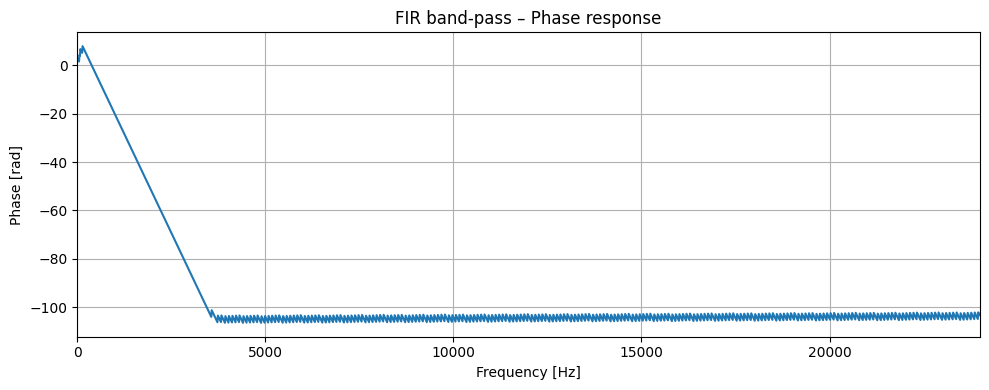

IIR band-pass phase response


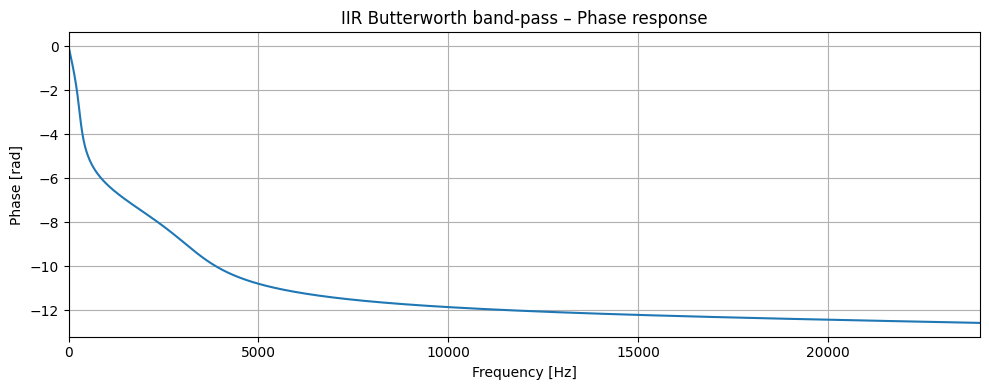

Interpretation:
- FIR phase should be approximately linear in the passband (straight line).
- IIR phase is generally nonlinear (curved), which may cause phase distortion.
- For intelligible speech, mild phase distortion is usually acceptable,
  but strong nonlinearities can smear transients such as consonant onsets.


In [10]:
# Phase responses

print("FIR band-pass phase response")
plot_phase_response(
    fir_filt["b"], fir_filt["a"], sr,
    title="FIR band-pass – Phase response",
)

print("IIR band-pass phase response")
plot_phase_response(
    iir_filt["b"], iir_filt["a"], sr,
    title="IIR Butterworth band-pass – Phase response",
)

print("Interpretation:")
print("- FIR phase should be approximately linear in the passband (straight line).")
print("- IIR phase is generally nonlinear (curved), which may cause phase distortion.")
print("- For intelligible speech, mild phase distortion is usually acceptable,")
print("  but strong nonlinearities can smear transients such as consonant onsets.")

---
### 1.4 Stability of the IIR Filter

Digital filter **stability** is determined by the locations of the **poles** of its transfer function:

- The IIR transfer function is \( H(z) = \frac{B(z)}{A(z)} \). The roots of \(A(z)\) are the **poles**.
- **Stability condition**: **all poles must lie strictly inside the unit circle** in the complex \(z\)-plane.
- We use `scipy.signal.tf2zpk` to compute **zeros** and **poles**, and then plot them.

We then state whether the designed Butterworth band‑pass filter is stable.

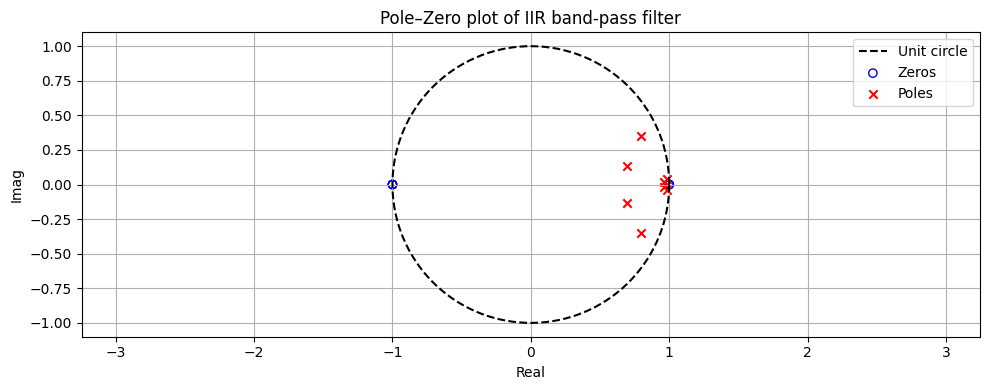

IIR filter stable? True
Poles magnitudes: [0.8700953  0.8700953  0.98701064 0.98701064 0.96002201 0.96002201
 0.71070891 0.71070891]
For a Butterworth design in SciPy, poles are expected to be inside the unit circle, hence stable.


In [11]:
# Poles and zeros of IIR band-pass filter

b_iir, a_iir = iir_filt["b"], iir_filt["a"]
z, p, k = signal.tf2zpk(b_iir, a_iir)

plt.figure()
# Unit circle
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "k--", label="Unit circle")
# Zeros and poles
plt.scatter(np.real(z), np.imag(z), marker="o", facecolors="none", edgecolors="b", label="Zeros")
plt.scatter(np.real(p), np.imag(p), marker="x", color="r", label="Poles")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.title("Pole–Zero plot of IIR band-pass filter")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Stability check
stable = np.all(np.abs(p) < 1.0)
print(f"IIR filter stable? {stable}")
print("Poles magnitudes:", np.abs(p))
print("For a Butterworth design in SciPy, poles are expected to be inside the unit circle, hence stable.")

---
## SECTION 2 — Frequency-Domain Analysis

We now analyze the speech signal in the frequency domain:

- **FFT spectrum** for global frequency content.
- **STFT spectrogram** for time–frequency structure of non‑stationary speech.
- **Wavelet scalogram** for multi‑resolution time–frequency analysis.
- **PSD via Welch’s method** for averaged power distribution over frequency.

### 2.1 FFT Analysis

The **Fast Fourier Transform (FFT)** decomposes the signal into sinusoidal components:

- The **magnitude spectrum** shows how much energy is present at each frequency.
- For speech, energy is typically concentrated at low frequencies:
  - Fundamental frequency (pitch) ~80–300 Hz.
  - Harmonics and broad formant bands mostly below ~4–5 kHz.

We compute the FFT of the **raw** and **filtered** signals and compare spectra.

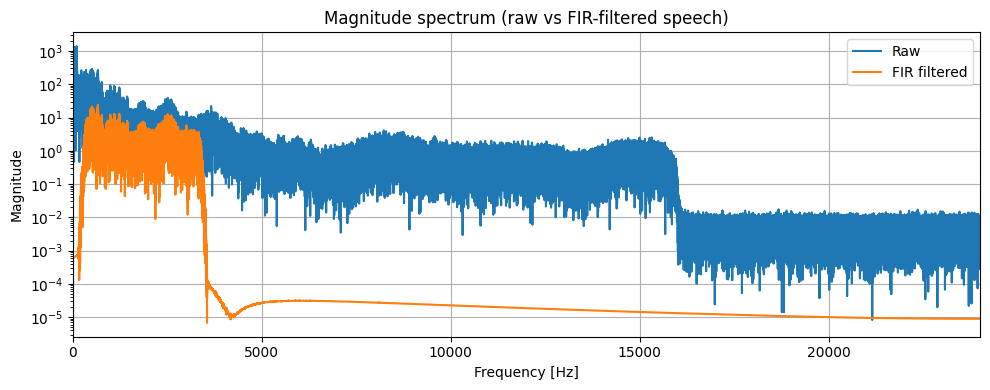

Interpretation:
- Raw speech may show energy at very low and very high frequencies (e.g., DC offset, noise).
- After band-pass filtering, energy is concentrated between ~300–3400 Hz,
  consistent with typical telephony-band speech.


In [12]:
# FFT of raw and FIR-filtered speech

freqs_raw, mag_raw = compute_fft(y, sr)
freqs_fir, mag_fir = compute_fft(y_fir, sr)

plt.figure()
plt.semilogy(freqs_raw, mag_raw, label="Raw")
plt.semilogy(freqs_fir, mag_fir, label="FIR filtered")
plt.xlim(0, sr / 2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Magnitude spectrum (raw vs FIR-filtered speech)")
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Raw speech may show energy at very low and very high frequencies (e.g., DC offset, noise).")
print("- After band-pass filtering, energy is concentrated between ~300–3400 Hz,")
print("  consistent with typical telephony-band speech.")

### 2.2 Short-Time Fourier Transform (STFT) and Spectrogram

Speech is a **non‑stationary** signal: its spectral content changes over time (vowels vs consonants, pauses, etc.).

- The **STFT** computes the FFT on short overlapping frames.
- The **spectrogram** shows energy vs **time and frequency**.
- Window length and hop size control time and frequency resolution.

We use `librosa.stft` to compute a spectrogram of the filtered speech.

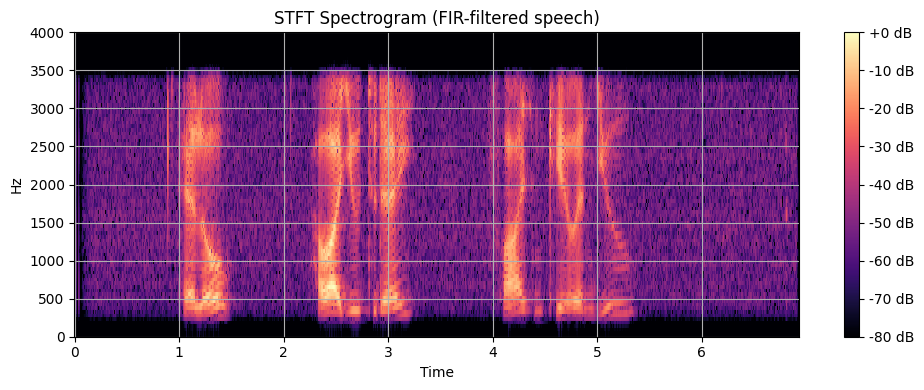

Interpretation:
- Time axis shows evolution of spectral content during the utterance.
- Horizontal bands correspond to harmonics/formants; bursts and fricatives appear as broadband regions.
- Non-stationarity of speech motivates using time–frequency tools like STFT.


In [13]:
# STFT spectrogram of FIR-filtered speech

n_fft = 1024
hop_length = 256

S_db = compute_stft(y_fir, sr, n_fft=n_fft, hop_length=hop_length, window="hann")

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    cmap="magma",
)
plt.colorbar(format="%+2.0f dB")
plt.title("STFT Spectrogram (FIR-filtered speech)")
plt.ylim(0, 4000)  # focus on speech band
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Time axis shows evolution of spectral content during the utterance.")
print("- Horizontal bands correspond to harmonics/formants; bursts and fricatives appear as broadband regions.")
print("- Non-stationarity of speech motivates using time–frequency tools like STFT.")

### 2.3 Wavelet Transform and Scalogram

The **Continuous Wavelet Transform (CWT)** provides a multi‑resolution analysis:

- High frequencies: good time resolution, coarser frequency resolution.
- Low frequencies: good frequency resolution, coarser time resolution.
- This is well suited for **non‑stationary** signals like speech.

Comparison with STFT:

- STFT uses a **fixed window size** → constant time–frequency resolution.
- Wavelets adapt resolution as a function of frequency.

We compute a **wavelet scalogram** using `pywt.cwt`.

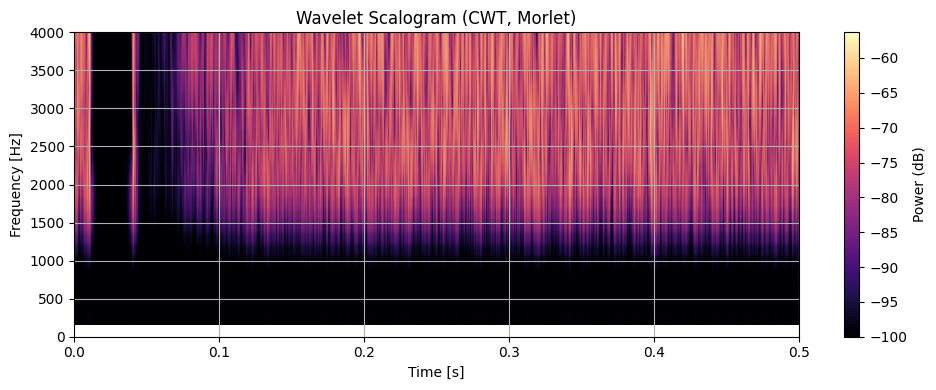

In [14]:
# Wavelet scalogram of a short segment (to keep plot compact)

dur = len(y_fir) / sr

start_s = 0.0
end_s = min(0.5, dur)   # use first 0.5s only

start = int(start_s * sr)
end = int(end_s * sr)

# if signal extremely short
y_seg = y_fir[start:end] if end > start else y_fir

# compute CWT
coeffs, freqs_w = compute_wavelet(
    y_seg,
    sr,
    wavelet="morl",
    max_scale=256      # increase scale for better frequency resolution
)

# scalogram power
power = np.abs(coeffs) ** 2
power_db = 10 * np.log10(power + 1e-10)

plt.figure(figsize=(10,4))

extent = [
    start_s,
    end_s,
    freqs_w.min(),
    freqs_w.max()
]

plt.imshow(
    power_db,
    extent=extent,
    aspect="auto",
    cmap="magma",
    origin="lower"
)

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Wavelet Scalogram (CWT, Morlet)")
plt.colorbar(label="Power (dB)")

plt.ylim(0,4000)

plt.tight_layout()
plt.show()

### 2.4 Power Spectral Density (PSD) via Welch's Method

The **Power Spectral Density (PSD)** describes how the signal’s **power** is distributed over frequency.

- Welch’s method averages periodograms over overlapping segments:
  - Reduces variance compared to a single FFT.
  - Provides a smooth estimate of spectral energy.

We compute and plot PSD of the **FIR‑filtered** speech.

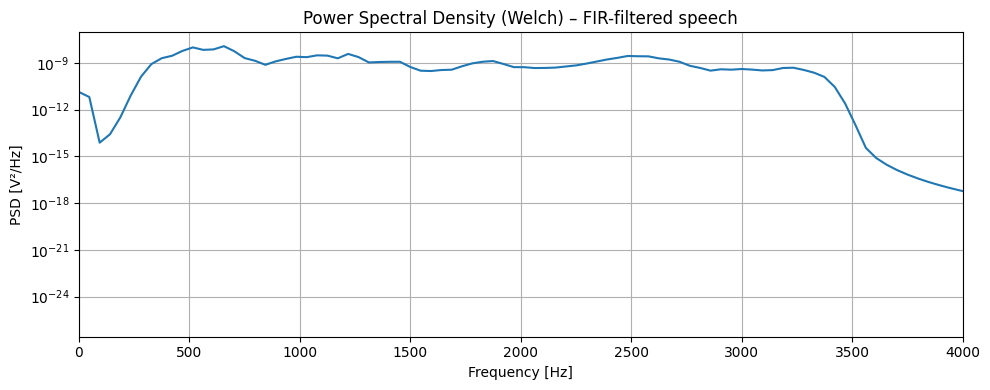

Interpretation:
- PSD highlights where the signal energy is concentrated across frequency.
- Most speech power is in low-to-mid frequencies (< 3–4 kHz).


In [15]:
# PSD of FIR-filtered speech using Welch's method

freqs_psd, psd = compute_psd(y_fir, sr, nperseg=1024)

plt.figure()
plt.semilogy(freqs_psd, psd)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.title("Power Spectral Density (Welch) – FIR-filtered speech")
plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- PSD highlights where the signal energy is concentrated across frequency.")
print("- Most speech power is in low-to-mid frequencies (< 3–4 kHz).")

---
## SECTION 3 — Required Signal Analysis

We now perform the specific analyses requested:

- **Spectral leakage** with different windows.
- **Window size effects** in spectrograms.
- **Time–frequency resolution trade‑off**.

### 3.1 Spectral Leakage

**Spectral leakage** occurs when a finite‑length signal segment does not contain an integer number of periods of a sinusoid:

- Using a **rectangular window** is equivalent to truncation; its Fourier transform has large sidelobes → leakage of energy into neighboring frequency bins.
- Using a **tapered window** (e.g., Hamming) reduces sidelobes and thus leakage, at the cost of slightly wider main lobe (reduced frequency resolution).

We demonstrate this using a pure sinusoid at a non‑integer frequency, comparing:

- FFT with rectangular window.
- FFT with Hamming window.

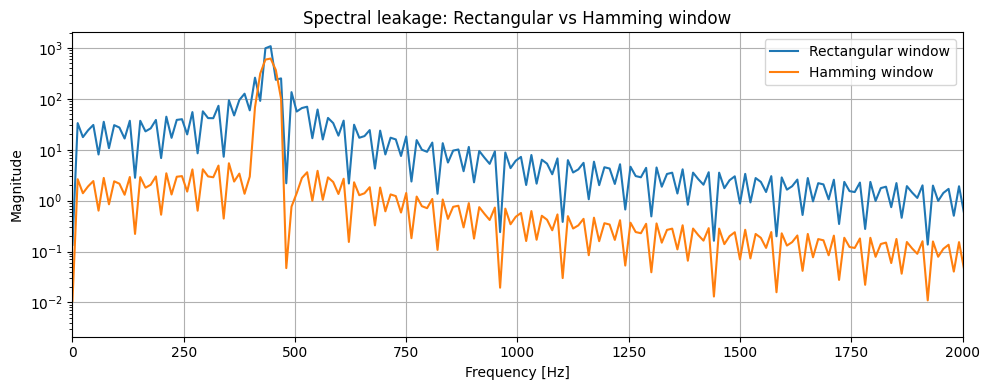

Interpretation:
- Rectangular window yields strong sidelobes: energy spreads to neighboring frequencies.
- Hamming window suppresses sidelobes, reducing leakage around the main tone frequency.
- This illustrates why windowing is important in spectral analysis of finite-length signals.


In [25]:
# Spectral leakage demonstration using a synthetic sinusoid

leak_sr = sr  # reuse audio sample rate
duration = 0.05  # 50 ms
t = np.arange(int(leak_sr * duration)) / leak_sr

# Choose a frequency that is not an integer multiple of FFT bin spacing
f_tone = 440.5  # Hz
x = np.sin(2 * np.pi * f_tone * t)

# Rectangular window (no taper)
rect = np.ones_like(x)

# Hamming window
ham = np.hamming(len(x))

# FFTs
N_fft = 4096
X_rect = np.fft.rfft(x * rect, n=N_fft)
X_ham = np.fft.rfft(x * ham, n=N_fft)
freqs_fft = np.fft.rfftfreq(N_fft, d=1.0 / leak_sr)

plt.figure(figsize=(10, 4))
plt.semilogy(freqs_fft, np.abs(X_rect), label="Rectangular window")
plt.semilogy(freqs_fft, np.abs(X_ham), label="Hamming window")
plt.xlim(0, 2000)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Spectral leakage: Rectangular vs Hamming window")
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Rectangular window yields strong sidelobes: energy spreads to neighboring frequencies.")
print("- Hamming window suppresses sidelobes, reducing leakage around the main tone frequency.")
print("- This illustrates why windowing is important in spectral analysis of finite-length signals.")

### 3.2 Window Size Effects in Spectrograms

The STFT window size controls the **time–frequency resolution trade‑off**:

- **Small window** (short duration):
  - Good time resolution (transients localized in time).
  - Poor frequency resolution (spectral lines broadened).
- **Large window** (long duration):
  - Good frequency resolution (sharper spectral details).
  - Poor time resolution (events smeared over time).

We compare spectrograms with a **small** and **large** window on the same speech signal.

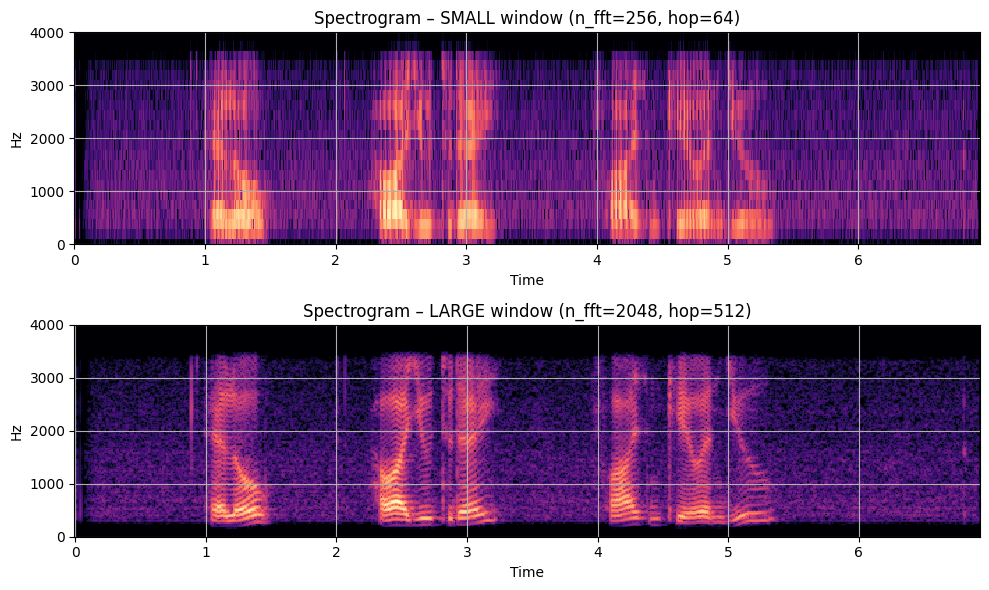

Observation:
- Small window: sharp in time (onsets and offsets well localized), but spectral bands look blurrier.
- Large window: sharper spectral bands (better frequency resolution), but events are smeared in time.


In [26]:
# Compare spectrograms with small vs large window sizes

small_n_fft = 256
small_hop = 64

large_n_fft = 2048
large_hop = 512

S_small = compute_stft(y_fir, sr, n_fft=small_n_fft, hop_length=small_hop, window="hann")
S_large = compute_stft(y_fir, sr, n_fft=large_n_fft, hop_length=large_hop, window="hann")

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(
    S_small,
    sr=sr,
    hop_length=small_hop,
    x_axis="time",
    y_axis="hz",
    cmap="magma",
)
plt.title(f"Spectrogram – SMALL window (n_fft={small_n_fft}, hop={small_hop})")
plt.ylim(0, 4000)

plt.subplot(2, 1, 2)
librosa.display.specshow(
    S_large,
    sr=sr,
    hop_length=large_hop,
    x_axis="time",
    y_axis="hz",
    cmap="magma",
)
plt.title(f"Spectrogram – LARGE window (n_fft={large_n_fft}, hop={large_hop})")
plt.ylim(0, 4000)

plt.tight_layout()
plt.show()

print("Observation:")
print("- Small window: sharp in time (onsets and offsets well localized), but spectral bands look blurrier.")
print("- Large window: sharper spectral bands (better frequency resolution), but events are smeared in time.")

### 3.3 Time–Frequency Resolution Trade-off

The **time–frequency resolution trade‑off** is fundamental:

- Short windows ⇒ good time resolution, poor frequency resolution.
- Long windows ⇒ good frequency resolution, poor time resolution.
- STFT uses a **fixed window**: you must choose a compromise suited to your application.
- Wavelet transforms change resolution with frequency, partially alleviating this trade‑off.

Using the spectrograms above:

- The **small‑window STFT** is ideal for analyzing rapid transient events (plosives, fricatives).
- The **large‑window STFT** is better for analyzing stable vowels and harmonic structure.

In practice, DSP for speech often combines multiple representations (FFT, STFT, wavelets, PSD) to capture complementary aspects of the signal.

---
## Conclusion

This notebook has implemented a complete DSP pipeline for **speech signal preprocessing and analysis**:

- Designed and compared **FIR (linear phase)** and **IIR Butterworth (efficient, nonlinear phase)** band‑pass filters for 300–3400 Hz, including frequency, phase, and stability analysis.
- Analyzed speech in the **frequency domain** via FFT, STFT spectrogram, wavelet scalogram, and PSD.
- Demonstrated key DSP concepts: **spectral leakage**, **windowing**, **window size effects**, and the **time–frequency resolution trade‑off**.

The modular functions:

- `load_audio()`
- `design_filter()`
- `apply_filter()`
- `plot_frequency_response()`
- `plot_phase_response()`
- `compute_fft()`
- `compute_stft()`
- `compute_wavelet()`
- `compute_psd()`

provide a reusable framework for further experiments in speech DSP and feature extraction.